### imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from sympy import diff as dif

from astropy.io import ascii
import astropy.units as u
import astropy.constants as const
from astropy.modeling.powerlaws import BrokenPowerLaw1D, SmoothlyBrokenPowerLaw1D, PowerLaw1D
from astropy.modeling import fitting, models
from scipy.stats import chisquare as CHI

## data

# V407 Cyg

### Freq 5 GHZ

In [2]:
#VLBA observation
#from Giroletti et al. 2020
#only using the SE region like they did in their paper

f5_VLBI = (
    [20, 5, 0.24, 0],  #EVN
    [31, 5, 1.8, 0], #VLBA
    [36, 5, 2.36, 0], #VLBA
    [70, 5, 7.1, 0], #EVN
    [72, 5, 4.1, 0], #VLBA
    [182, 5, 0.5, 0],
)

#making the dataframes for the frequency
VLBI_407 = pd.DataFrame(f5_VLBI, columns = ["Days","Freq","Flux","Error"])

days5_VLBI = VLBI_407['Days']
flux5_VLBI = VLBI_407["Flux"]
flux_err5_VLBI = np.sqrt(VLBI_407["Error"]**2 + (VLBI_407["Flux"]*0.05)**2)

In [3]:
#fit

fit5_VLBI = (
    #[20, 5, 0.24, 0],  #EVN
    #[31, 5, 1.8, 0], #VLBA
    #[36, 5, 2.36, 0], #VLBA
    [70, 5, 7.1, 0], #EVN
    [72, 5, 4.1, 0], #VLBA
    [182, 5, 0.5, 0],
)

#making the dataframes for the frequency
VLBI_407_fit = pd.DataFrame(fit5_VLBI, columns = ["Days","Freq","Flux","Error"])

days5_VLBIfit = VLBI_407_fit['Days']
flux5_VLBIfit = VLBI_407_fit["Flux"]
flux_err5_VLBIfit = np.sqrt(VLBI_407_fit["Error"]**2 + (VLBI_407_fit["Flux"]*0.05)**2)

x0 = days5_VLBIfit.values.tolist()
y0 = flux5_VLBIfit.values.tolist()
yerr0 = flux_err5_VLBIfit.values.tolist() 




PL0 =  PowerLaw1D(amplitude = y0[0], x_0= x0[0], alpha= -1.4,
                     bounds={
        'amplitude': (0, None),  # Amplitude should be positive
        #'x_0': (x3[0], x3[0]),  # Frequency must stay within data
        'alpha': (-10, 10)  # Keep alpha within a realistic range
    },
                 fixed={'x_0': True}) 

    #Initialize fitters
    #setting calc_uncertainties=True to output errors on measurement 

fit = fitting.LevMarLSQFitter(calc_uncertainties=True)

    #Fit the data w/o weights
fit_model0 = fit(PL0, x0, y0)

    #weight is 1/error^2
y_weight0 = 1/ (np.power(yerr0,2))  

    # fit the data using the uncertainties as weights
fit_model_weights0 = fit(PL0, x0, y0, weights=y_weight0)

fit_model_weights0

<PowerLaw1D(amplitude=4.69438932, x_0=70., alpha=2.34382223)>

In [4]:
#VLA data

#defing frequency 5
f5 = (
    #5
    [55282.9,    1.0,  5.0,  6.389,  0.000,  0.150,  0.050],
    [55284.8,    2.0,  5.0,  7.034,  0.000,  0.104,  0.050],
    [55625.4,   25.0,  5.0,  5.003,  0.000,  0.027,  0.050],
    [55735.4,   26.0,  5.0,  3.270,  0.000,  0.029,  0.050],
    [55869.1,   27.0,  5.0,  3.542,  0.000,  0.036,  0.050],
    [55934.8,   28.0,  5.0,  3.212,  0.055,  0.000,  0.050],
    [56035.4,   29.0,  5.0,  2.913,  0.028,  0.000,  0.050], 

    #4.8
    [55289.7,    3.0,  4.8,  6.880,  0.000,  0.130,  0.050],
    [55294.7,    4.0,  4.8,  8.990,  0.000,  0.130,  0.050],
    [55298.7,    5.0,  4.8, 10.680,  0.000,  0.110,  0.050],
    [55301.7,    6.0,  4.8, 12.363,  0.182,  0.051,  0.050],
    [55304.7,    7.0,  4.8, 12.792,  0.167,  0.039,  0.050],
    [55308.7,    8.0,  4.8, 13.690,  0.171,  0.034,  0.050],
    [55311.6,    9.0,  4.8, 13.964,  0.078,  0.014,  0.050],
    [55315.6,   10.0,  4.8, 13.673,  0.107,  0.027,  0.050],
    [55318.6,   11.0,  4.8, 13.135,  0.130,  0.028,  0.050],
    [55323.6,   12.0,  4.8, 14.160,  0.088,  0.016,  0.050],
    [55330.5,   13.0,  4.8, 15.023,  0.082,  0.023,  0.050],
    [55332.6,   14.0,  4.8, 15.479,  0.000,  0.155,  0.050],
    [55341.6,   15.0,  4.8, 17.395,  0.092,  0.032,  0.050],
    [55345.6,   16.0,  4.8, 17.465,  0.000,  0.165,  0.050],
    [55362.5,   17.0,  4.8, 17.255,  0.061,  0.016,  0.050],
    [55367.6,	  18.0,	4.8, 17.777,  0.145,  0.032,  0.050],	
    [55368.5,	  19.0,	4.8, 17.446,  0.000,  0.135,  0.050],
    [55404.4,   20.0,  4.8, 12.926,  0.083,  0.022,  0.050],
    [55419.3,	  21.0,	4.8, 11.805,  0.118,  0.018,  0.050],
    [55434.3,	  22.0,	4.8, 10.785,  0.100,  0.018,  0.050],
    [55449.2,	  23.0,  4.8,  9.979,  0.115,  0.024,  0.050],
    [55469.2,	  24.0,	4.8,  9.173,  0.074,  0.000,  0.050], 
)




#making the dataframes for the frequency
VLA_407 = pd.DataFrame(f5, columns = ["MJD","Epoch","Freq","Flux","Error1 (gaussfit)","Error2 (image)","Error3 (calibration) (%)",])

days5_VLA = VLA_407['MJD']-55265.2
flux5_VLA = VLA_407["Flux"]
flux_err5_VLA = np.sqrt(VLA_407["Error1 (gaussfit)"]**2 + (VLA_407["Flux"]*0.05)**2)


In [5]:
#fit

fit5 = (
    #5
    #[55282.9,    1.0,  5.0,  6.389,  0.000,  0.150,  0.050],
    #[55284.8,    2.0,  5.0,  7.034,  0.000,  0.104,  0.050],
    #[55625.4,   25.0,  5.0,  5.003,  0.000,  0.027,  0.050],
    #[55735.4,   26.0,  5.0,  3.270,  0.000,  0.029,  0.050],
    #[55869.1,   27.0,  5.0,  3.542,  0.000,  0.036,  0.050],
    #[55934.8,   28.0,  5.0,  3.212,  0.055,  0.000,  0.050],
    #[56035.4,   29.0,  5.0,  2.913,  0.028,  0.000,  0.050], 

    #4.8
    #[55289.7,    3.0,  4.8,  6.880,  0.000,  0.130,  0.050],
    #[55294.7,    4.0,  4.8,  8.990,  0.000,  0.130,  0.050],
    #55298.7,    5.0,  4.8, 10.680,  0.000,  0.110,  0.050],
    #[55301.7,    6.0,  4.8, 12.363,  0.182,  0.051,  0.050],
    #[55304.7,    7.0,  4.8, 12.792,  0.167,  0.039,  0.050],
    #[55308.7,    8.0,  4.8, 13.690,  0.171,  0.034,  0.050],
    #[55311.6,    9.0,  4.8, 13.964,  0.078,  0.014,  0.050],
    #[55315.6,   10.0,  4.8, 13.673,  0.107,  0.027,  0.050],
    #[55318.6,   11.0,  4.8, 13.135,  0.130,  0.028,  0.050],
    #[55323.6,   12.0,  4.8, 14.160,  0.088,  0.016,  0.050],
    #[55330.5,   13.0,  4.8, 15.023,  0.082,  0.023,  0.050],
    [55332.6,   14.0,  4.8, 15.479,  0.000,  0.155,  0.050],
    [55341.6,   15.0,  4.8, 17.395,  0.092,  0.032,  0.050],
    [55345.6,   16.0,  4.8, 17.465,  0.000,  0.165,  0.050],
    [55362.5,   17.0,  4.8, 17.255,  0.061,  0.016,  0.050],
    [55367.6,	  18.0,	4.8, 17.777,  0.145,  0.032,  0.050],	
    [55368.5,	  19.0,	4.8, 17.446,  0.000,  0.135,  0.050],
    [55404.4,   20.0,  4.8, 12.926,  0.083,  0.022,  0.050],
    [55419.3,	  21.0,	4.8, 11.805,  0.118,  0.018,  0.050],
    [55434.3,	  22.0,	4.8, 10.785,  0.100,  0.018,  0.050],
    [55449.2,	  23.0,  4.8,  9.979,  0.115,  0.024,  0.050],
    [55469.2,	  24.0,	4.8,  9.173,  0.074,  0.000,  0.050], 
)




#making the dataframes for the frequency
VLA_407fit = pd.DataFrame(fit5, columns = ["MJD","Epoch","Freq","Flux","Error1 (gaussfit)","Error2 (image)","Error3 (calibration) (%)",])

days5_VLAfit = VLA_407fit['MJD']-55265.2
flux5_VLAfit = VLA_407fit["Flux"]
flux_err5_VLAfit = np.sqrt(VLA_407fit["Error1 (gaussfit)"]**2 + (VLA_407fit["Flux"]*0.05)**2)


x1 = days5_VLAfit.values.tolist()
y1 = flux5_VLAfit.values.tolist()
yerr1 = flux_err5_VLAfit.values.tolist() 




PL1 =  PowerLaw1D(amplitude = y1[0], x_0= x1[0], alpha= -1.4,
                     bounds={
        'amplitude': (0, None),  # Amplitude should be positive
        #'x_0': (x3[0], x3[0]),  # Frequency must stay within data
        'alpha': (-10, 10)  # Keep alpha within a realistic range
    },
                 fixed={'x_0': True}) 

    #Initialize fitters
    #setting calc_uncertainties=True to output errors on measurement 

fit = fitting.LevMarLSQFitter(calc_uncertainties=True)

    #Fit the data w/o weights
fit_model1 = fit(PL1, x1, y1)

    #weight is 1/error^2
y_weight1 = 1/ (np.power(yerr1,2))  

    # fit the data using the uncertainties as weights
fit_model_weights1 = fit(PL1, x1, y1, weights=y_weight1)

fit_model_weights1

<PowerLaw1D(amplitude=18.71267116, x_0=67.4, alpha=0.59792539)>

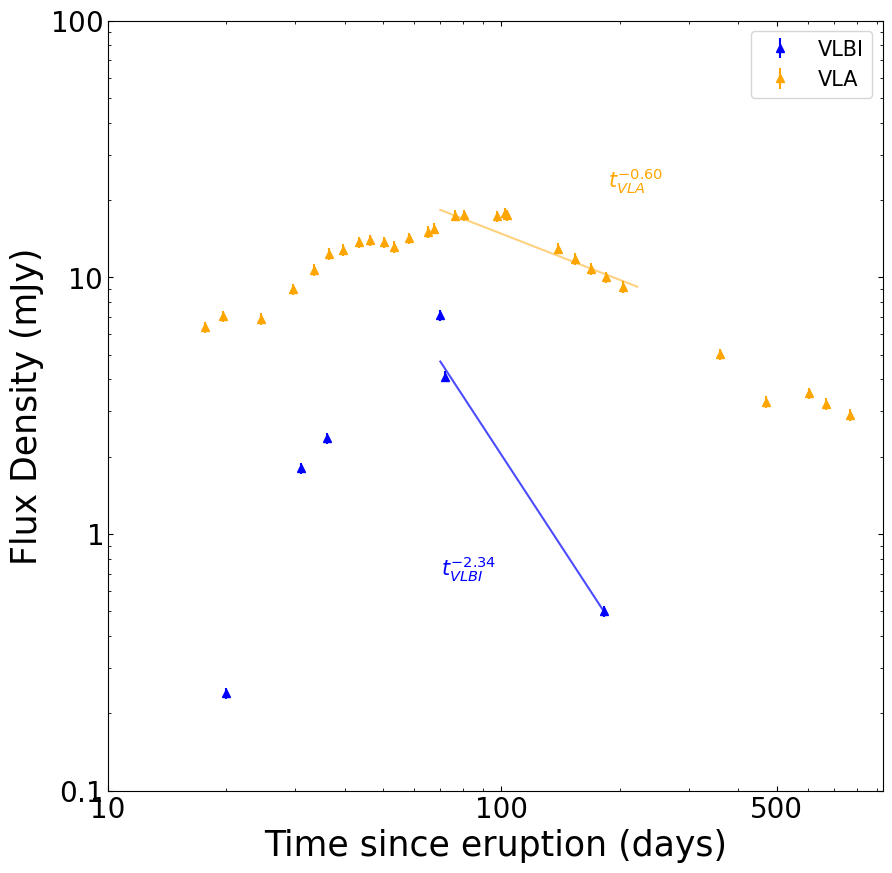

In [28]:
#plotting

fig, ax = plt.subplots()
fig.set_size_inches(10,10)

# Store which labels have already been used
used_labels = set()

def plot(days, fluxes, errors, color, label_name):
    for day, flux, err in zip(days, fluxes, errors):
        if flux < 3 * err:
            fmt = 'x'  # square for non-detection
            label = None  # no label for non-detections

            ax.errorbar(day, (flux+3*err), fmt=fmt, color=color, label=label)
            
        if flux > 3*err :
            fmt = '^'  # triangle for detection
            label = label_name if label_name not in used_labels else None
        
            ax.errorbar(day, flux, yerr=err, fmt=fmt, color=color, label=label)
        
        if label:
            used_labels.add(label)

x_freq = np.arange(70,182,0.5)
plot(days5_VLBI, flux5_VLBI, flux_err5_VLBI, 'blue', 'VLBI')
ax.plot(x_freq, fit_model_weights0(x_freq), color='blue', linestyle = '-', alpha=.70)
ax.annotate('$t_{VLBI}^{-2.34}$', xy=(280, 170), xycoords='axes points', size=15, color='blue', ha='right', va='top', bbox=dict(boxstyle='round', fc='w', ec="w"))


x_freq1 = np.arange(70,222,0.5)
plot(days5_VLA, flux5_VLA, flux_err5_VLA, 'orange', "VLA")
#plot(days5_VLAfit, flux5_VLAfit, flux_err5_VLAfit, 'red', "Vtest")
ax.plot(x_freq1, fit_model_weights1(x_freq1), color='orange',  linestyle = '-', alpha=.50)
ax.annotate('$t_{VLA}^{-0.60}$', xy=(400, 450), xycoords='axes points', size=15, color='orange', ha='right', va='top', bbox=dict(boxstyle='round', fc='w', ec="w"))


# Final plot formatting
ax.set_xscale('log')
ax.set_xticks([10,100,500], labels = ['10','100','500'], fontsize = 20)
ax.set_yscale('log')
ax.set_yticks([0.1, 1,10, 100], labels = [r'$0.1$', r'$1$', r'$10$', r'$100$'], fontsize = 20)
ax.set_xlabel("Time since eruption (days)", fontsize = 25)
ax.set_ylabel("Flux Density (mJy)", fontsize = 25)

ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)

ax.set_title("")
plt.legend(fontsize = 15)
plt.savefig("V407Cyg_VLA_vs_VLBA_lc.png")
plt.show()

In [47]:
#point 1
print("First VLBI point")
#VLBI data
#[20, 5, 0.24, 0],  #EVN
   
   

#VLA data
#day 19.6
# #[55284.8,    2.0,  5.0,  7.034,  0.000,  0.104,  0.050],

VLBI1 = 0.24
VLA1 = 7.034

diff1 = VLBI1/VLA1

print("Same freq at this point")
print('')
print("The VLBI gets", diff1*100, "% of the VLA data at point 1")

perchange1 = (VLBI1-VLA1)/VLA1
print("The percentage change between the VLA to VLBI data for point 1 is", perchange1*100, "%")

perdif1 = np.abs((VLBI1-VLA1)/((VLBI1+VLA1)/2)) * 100
print("The percentage difference between the VLA and VLBI in the first point is", perdif1, "%")



#point 2
print(" ")
print("Second VLBI point")
#VLBI data
# [31, 5, 1.8, 0], #VLBA
   

#VLA data
#day 33.5
#[55298.7,    5.0,  4.8, 10.680,  0.000,  0.110,  0.050],

VLBI2 = 1.8
VLA2 = 10.68

diff2 = VLBI2/VLA2

print("keep in mind there is a difference of 0.2 in the frequency, VLBI data from 5 GHz and VLA data from 4.8 GHz")
print('')
print("The VLBI gets", diff2*100, "% of the VLA data at point 2")

perchange2 = (VLBI2-VLA2)/VLA2
print("The percentage change between the VLA to VLBI data for point 2 is", perchange2*100, "%")

perdif2 = np.abs((VLBI2-VLA2)/((VLBI2+VLA2)/2)) * 100
print("The percentage difference between the VLA and VLBI in the 2nd point is", perdif2, "%")



#point 3
print(" ")
print("Third VLBI point")
#VLBI data
#[36, 5, 2.36, 0], #VLBA

#VLA data
#day 36.5
##[55301.7,    6.0,  4.8, 12.363,  0.182,  0.051,  0.050],


VLBI3 = 2.36
VLA3 = 12.363

diff3 = VLBI3/VLA3

print("keep in mind there is a difference of 0.2 in the frequency, VLBI data from 5 GHz and VLA data from 4.8 GHz")
print('')
print("The VLBI gets", diff3*100, "% of the VLA data at point 3")

perchange3 = (VLBI3-VLA3)/VLA3
print("The percentage change between the VLA to VLBI data for point 3 is", perchange3*100, "%")

perdif3 = np.abs((VLBI3-VLA3)/((VLBI3+VLA3)/2)) * 100
print("The percentage difference between the VLA and VLBI in the 3rd point is", perdif3, "%")




#point 4
print(" ")
print("Fourth VLBI point")
#VLBI data
# [70, 5, 7.1, 0], #EVN
   
#VLA data
#day 67.4
#[55332.6,   14.0,  4.8, 15.479,  0.000,  0.155,  0.050],


VLBI4 = 7.1
VLA4 = 15.479

diff4 = VLBI4/VLA4

print("keep in mind there is a difference of 0.2 in the frequency, VLBI data from 5 GHz and VLA data from 4.8 GHz")
print('')
print("The VLBI gets", diff4*100, "% of the VLA data at point 4")

perchange4 = (VLBI4-VLA4)/VLA4
print("The percentage change between the VLA to VLBI data for point 4 is", perchange4*100, "%")

perdif4 = np.abs((VLBI4-VLA4)/((VLBI4+VLA4)/2)) * 100
print("The percentage difference between the VLA and VLBI in the 4th point is", perdif4, "%")



#point 5
print(" ")
print("Fifth VLBI point")
#VLBI data
#[72, 5, 4.1, 0], #VLBA
   
   
#VLA data
#day 76.4
#    [55341.6,   15.0,  4.8, 17.395,  0.092,  0.032,  0.050],


VLBI5 = 4.1
VLA5 = 17.395

diff5 = VLBI5/VLA5

print("keep in mind there is a difference of 0.2 in the frequency, VLBI data from 5 GHz and VLA data from 4.8 GHz")
print('')
print("The VLBI gets", diff5*100, "% of the VLA data at point 5")

perchange5 = (VLBI5-VLA5)/VLA5
print("The percentage change between the VLA to VLBI data for point 5 is", perchange5*100, "%")

perdif5 = np.abs((VLBI5-VLA5)/((VLBI5+VLA5)/2)) * 100
print("The percentage difference between the VLA and VLBI in the 5th point is", perdif5, "%")


#point 6
print(" ")
print("Sixth VLBI point")
#VLBI data
# [182, 5, 0.5, 0],
   
   
#VLA data
#day 184
#[55449.2,	  23.0,  4.8,  9.979,  0.115,  0.024,  0.050],



VLBI6 = 0.5
VLA6 = 9.979

diff6 = VLBI6/VLA6

print("keep in mind there is a difference of 0.2 in the frequency, VLBI data from 5 GHz and VLA data from 4.8 GHz")
print('')
print("The VLBI gets", diff5*100, "% of the VLA data at point 6")

perchange6 = (VLBI6-VLA6)/VLA6
print("The percentage change between the VLA to VLBI data for point 6 is", perchange6*100, "%")

perdif6 = np.abs((VLBI6-VLA6)/((VLBI6+VLA6)/2)) * 100
print("The percentage difference between the VLA and VLBI in the 6th point is", perdif6, "%")



print(" ")
print("Average:")

#averaging those points

avediff = (diff1+diff2+diff3+diff4+diff5+diff6)/6
avediffper = avediff*100

print("the average difference in the VLBI vs VLA data between the six points is", avediffper, "%")


#ave percent change

aveperchange = ((perchange1+perchange2+perchange3+perchange4+perchange5+perchange6)/6)*100
print("")
print("The average petcentage change between the VLA and VLBI data for the points is", aveperchange, "%")

aveperdif = ((perdif1+perdif2+perdif3+perdif4+perdif5+perdif6)/6)
print("")
print("The average petcentage change between the VLA and VLBI data for the points is", aveperdif, "%")


print(" ")
print("Slope:")

#overall slope

VLBIslope =  -0.03155471
VLAslope =  -0.40519006

diffslope = np.abs(VLBIslope - VLAslope)

print("keep in mind there is a difference of 0.2 in the frequency, VLBI data from 5 GHz and VLA data from 4.8 GHz")
print('')
print("The difference in the slope is", diffslope)
print('')

perchangeslope = (VLBIslope-VLAslope)/VLAslope
print("The percentage change between the VLA to VLBI data for the slope is", perchangeslope*100, "%")

print("")

perdifslope = np.abs((VLBIslope-VLAslope)/((VLBIslope+VLAslope)/2)) * 100
print("The percentage difference between the VLA and VLBI in the slope is", perdifslope, "%")

First VLBI point
Same freq at this point

The VLBI gets 3.4119988626670454 % of the VLA data at point 1
The percentage change between the VLA to VLBI data for point 1 is -96.58800113733295 %
The percentage difference between the VLA and VLBI in the first point is 186.8023095958207 %
 
Second VLBI point
keep in mind there is a difference of 0.2 in the frequency, VLBI data from 5 GHz and VLA data from 4.8 GHz

The VLBI gets 16.853932584269664 % of the VLA data at point 2
The percentage change between the VLA to VLBI data for point 2 is -83.14606741573033 %
The percentage difference between the VLA and VLBI in the 2nd point is 142.3076923076923 %
 
Third VLBI point
keep in mind there is a difference of 0.2 in the frequency, VLBI data from 5 GHz and VLA data from 4.8 GHz

The VLBI gets 19.089217827388175 % of the VLA data at point 3
The percentage change between the VLA to VLBI data for point 3 is -80.91078217261183 %
The percentage difference between the VLA and VLBI in the 3rd point is 1

### Freq 1.6 GHz

In [7]:
#VLBA observation
#from Giroletti et al. 2020
#only using the SE region like it looks like they did in their paper
#but this doesn't get the same results for some reason...

f1_VLBI = (
    [44, 1.6, 2.4, 0], #EVN
    [55, 1.6, 1.8, 0], #VLBA
    [72, 1.6, 1.7, 0], #VLBA
    [91, 1.6, 4.0, 0], #EVN
    [203, 1.6, 3.9, 0] #EVN
)

#making the dataframes for the frequency
VLBI_407_1 = pd.DataFrame(f1_VLBI, columns = ["Days","Freq","Flux","Error"])

days1_VLBI = VLBI_407_1['Days']
flux1_VLBI = VLBI_407_1["Flux"]
flux_err1_VLBI = np.sqrt(VLBI_407_1["Error"]**2 + (VLBI_407_1["Flux"]*0.05)**2)

In [29]:
#fit

fit1_VLBI = (
    #[44, 1.6, 2.4, 0], #EVN
    #[55, 1.6, 1.8, 0], #VLBA
    #[72, 1.6, 1.7, 0], #VLBA
    [91, 1.6, 4.0, 0], #EVN
    [203, 1.6, 3.9, 0] #EVN
)

#making the dataframes for the frequency
VLBI_407_fit_1 = pd.DataFrame(fit1_VLBI, columns = ["Days","Freq","Flux","Error"])

days1_VLBIfit = VLBI_407_fit_1['Days']
flux1_VLBIfit = VLBI_407_fit_1["Flux"]
flux_err1_VLBIfit = np.sqrt(VLBI_407_fit_1["Error"]**2 + (VLBI_407_fit_1["Flux"]*0.05)**2)

x01 = days1_VLBIfit.values.tolist()
y01 = flux1_VLBIfit.values.tolist()
yerr01 = flux_err1_VLBIfit.values.tolist() 




PL01 =  PowerLaw1D(amplitude = y01[0], x_0= x01[0], alpha= -1.4,
                     bounds={
        'amplitude': (0, None),  # Amplitude should be positive
        #'x_0': (x3[0], x3[0]),  # Frequency must stay within data
        'alpha': (-10, 10)  # Keep alpha within a realistic range
    },
                 fixed={'x_0': True}) 

    #Initialize fitters
    #setting calc_uncertainties=True to output errors on measurement 

fit = fitting.LevMarLSQFitter(calc_uncertainties=True)

    #Fit the data w/o weights
fit_model01 = fit(PL01, x01, y01)

    #weight is 1/error^2
y_weight01 = 1/ (np.power(yerr01,2))  

    # fit the data using the uncertainties as weights
fit_model_weights01 = fit(PL01, x01, y01, weights=y_weight01)

fit_model_weights01

<PowerLaw1D(amplitude=4., x_0=91., alpha=0.03155471)>

In [9]:
#VLA data

#defing frequency 1.8
f1 = (
     [55289.7,    3.0,  1.8,  3.469,  0.350,  0.000,  0.050],
    [55298.7,    5.0,  1.8,  4.762,  0.300,  0.000,  0.050],
    [55301.7,    6.0,  1.8,  5.466,  0.300,  0.000,  0.050],
    [55304.7,    7.0,  1.8,  5.512,  0.350,  0.000,  0.050],
    [55308.7,    8.0,  1.8,  6.662,  0.330,  0.000,  0.050],
    [55311.7,    9.0,  1.8,  6.841,  0.300,  0.000,  0.050],
    [55315.6,   10.0,  1.8,  7.376,  0.290,  0.000,  0.050],
    [55318.6 ,  11.0,  1.8,  7.478,  0.260,  0.000,  0.050],
    [55323.6,   12.0,  1.8,  7.657,  0.330,  0.000,  0.050],
    [55330.5,   13.0,  1.8,  6.651,  0.270,  0.000,  0.050],
    [55332.6,   14.0,  1.8,  7.574,  0.260,  0.000,  0.050],
    [55341.6,   15.0,  1.8,  8.049,  0.260,  0.000,  0.050],
    [55345.6,   16.0,  1.8,  7.532,  0.280,  0.000 , 0.050],
    [55362.5,   17.0,	1.8,  7.540,  0.240,  0.000,  0.050],
    [55367.6,	  18.0,  1.8,  7.811,  0.290,  0.000,  0.050],
    [55368.5,	  19.0,  1.8,  7.381,  0.260,  0.000,  0.050],
    [55404.4 ,  20.0,  1.8 , 8.225,  0.300,  0.000,  0.050],
    [55419.4,	  21.0,	1.8,  8.192 , 0.200,  0.000,  0.050],
    [55434.3,	  22.0,	1.8,  6.386,  0.240,  0.000,  0.050],
    [55449.2,	  23.0, 	1.8,  6.338,  0.160,  0.000,  0.050],
    [55469.2,	  24.0,	1.8,  5.532,  0.135,  0.000,  0.050],
    [55625.4,   25.0,  1.8,  4.644,  0.092,  0.000 , 0.050],
    [55735.4,   26.0,  1.8,  4.074,  0.068,  0.000,  0.050],
    [55869.1 ,  27.0,  1.8,  3.855,  0.291,  0.000,  0.050],
    [55934.8,   28.0,  1.8,  3.316,  0.554,  0.000,  0.050], #held width constant
    [56035.4,   29.0,  1.8,  3.347,  0.232,  0.000,  0.050]
)




#making the dataframes for the frequency
VLA_407_1 = pd.DataFrame(f1, columns = ["MJD","Epoch","Freq","Flux","Error1 (gaussfit)","Error2 (image)","Error3 (calibration) (%)",])

days1_VLA = VLA_407_1['MJD']-55265.2
flux1_VLA = VLA_407_1["Flux"]
flux_err1_VLA = np.sqrt(VLA_407_1["Error1 (gaussfit)"]**2 + (VLA_407_1["Flux"]*0.05)**2)


In [32]:
#fit

fit1 = (
    #[55289.7,    3.0,  1.8,  3.469,  0.350,  0.000,  0.050],
    #[55298.7,    5.0,  1.8,  4.762,  0.300,  0.000,  0.050],
    #[55301.7,    6.0,  1.8,  5.466,  0.300,  0.000,  0.050],
    #[55304.7,    7.0,  1.8,  5.512,  0.350,  0.000,  0.050],
    #[55308.7,    8.0,  1.8,  6.662,  0.330,  0.000,  0.050],
    #[55311.7,    9.0,  1.8,  6.841,  0.300,  0.000,  0.050],
    #[55315.6,   10.0,  1.8,  7.376,  0.290,  0.000,  0.050],
    #[55318.6 ,  11.0,  1.8,  7.478,  0.260,  0.000,  0.050],
    #[55323.6,   12.0,  1.8,  7.657,  0.330,  0.000,  0.050],
    #[55330.5,   13.0,  1.8,  6.651,  0.270,  0.000,  0.050],
    #[55332.6,   14.0,  1.8,  7.574,  0.260,  0.000,  0.050],
    #[55341.6,   15.0,  1.8,  8.049,  0.260,  0.000,  0.050],
    #[55345.6,   16.0,  1.8,  7.532,  0.280,  0.000 , 0.050],
    [55362.5,   17.0,	1.8,  7.540,  0.240,  0.000,  0.050],
    [55367.6,	  18.0,  1.8,  7.811,  0.290,  0.000,  0.050],
    [55368.5,	  19.0,  1.8,  7.381,  0.260,  0.000,  0.050],
    [55404.4 ,  20.0,  1.8 , 8.225,  0.300,  0.000,  0.050],
    [55419.4,	  21.0,	1.8,  8.192 , 0.200,  0.000,  0.050],
    [55434.3,	  22.0,	1.8,  6.386,  0.240,  0.000,  0.050],
    [55449.2,	  23.0, 	1.8,  6.338,  0.160,  0.000,  0.050],
    [55469.2,	  24.0,	1.8,  5.532,  0.135,  0.000,  0.050],
    #[55625.4,   25.0,  1.8,  4.644,  0.092,  0.000 , 0.050],
    #[55735.4,   26.0,  1.8,  4.074,  0.068,  0.000,  0.050],
    #[55869.1 ,  27.0,  1.8,  3.855,  0.291,  0.000,  0.050],
    #[55934.8,   28.0,  1.8,  3.316,  0.554,  0.000,  0.050], #held width constant
    #[56035.4,   29.0,  1.8,  3.347,  0.232,  0.000,  0.050]
)




#making the dataframes for the frequency
VLA_407fit1 = pd.DataFrame(fit1, columns = ["MJD","Epoch","Freq","Flux","Error1 (gaussfit)","Error2 (image)","Error3 (calibration) (%)",])

days1_VLAfit = VLA_407fit1['MJD']-55265.2
flux1_VLAfit = VLA_407fit1["Flux"]
flux_err1_VLAfit = np.sqrt(VLA_407fit1["Error1 (gaussfit)"]**2 + (VLA_407fit1["Flux"]*0.05)**2)


x11 = days1_VLAfit.values.tolist()
y11 = flux1_VLAfit.values.tolist()
yerr11 = flux_err1_VLAfit.values.tolist() 




PL11=  PowerLaw1D(amplitude = y11[0], x_0= x11[0], alpha= -1.4,
                     bounds={
        'amplitude': (0, None),  # Amplitude should be positive
        #'x_0': (x3[0], x3[0]),  # Frequency must stay within data
        'alpha': (-10, 10)  # Keep alpha within a realistic range
    },
                 fixed={'x_0': True}) 

    #Initialize fitters
    #setting calc_uncertainties=True to output errors on measurement 

fit = fitting.LevMarLSQFitter(calc_uncertainties=True)

    #Fit the data w/o weights
fit_model11 = fit(PL11, x11, y11)

    #weight is 1/error^2
y_weight11 = 1/ (np.power(yerr11,2))  

    # fit the data using the uncertainties as weights
fit_model_weights11 = fit(PL11, x11, y11, weights=y_weight11)

fit_model_weights11

<PowerLaw1D(amplitude=7.99768377, x_0=97.3, alpha=0.40519006)>

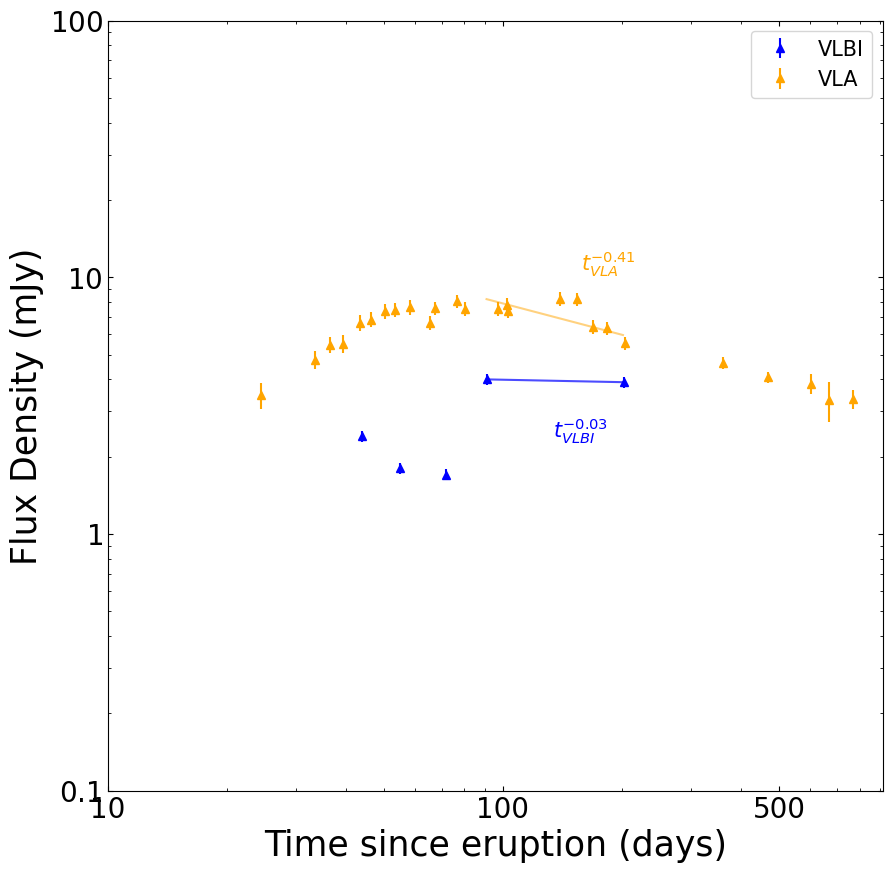

In [41]:
#plotting

fig, ax = plt.subplots()
fig.set_size_inches(10,10)

# Store which labels have already been used
used_labels = set()

def plot(days, fluxes, errors, color, label_name):
    for day, flux, err in zip(days, fluxes, errors):
        if flux < 3 * err:
            fmt = 'x'  # square for non-detection
            label = None  # no label for non-detections

            ax.errorbar(day, (flux+3*err), fmt=fmt, color=color, label=label)
            
        if flux > 3*err :
            fmt = '^'  # triangle for detection
            label = label_name if label_name not in used_labels else None
        
            ax.errorbar(day, flux, yerr=err, fmt=fmt, color=color, label=label)
        
        if label:
            used_labels.add(label)

x_freq = np.arange(91,202,0.5)
plot(days1_VLBI, flux1_VLBI, flux_err1_VLBI, 'blue', 'VLBI')
ax.plot(x_freq, fit_model_weights01(x_freq), color='blue', linestyle = '-', alpha=.70)
ax.annotate('$t_{VLBI}^{-0.03}$', xy=(360, 270), xycoords='axes points', size=15, color='blue', ha='right', va='top', bbox=dict(boxstyle='round', fc='w', ec="w"))


x_freq1 = np.arange(91,202,0.5)
plot(days1_VLA, flux1_VLA, flux_err1_VLA, 'orange', "VLA")
#plot(days5_VLAfit, flux5_VLAfit, flux_err5_VLAfit, 'red', "Vtest")
ax.plot(x_freq1, fit_model_weights11(x_freq1), color='orange',  linestyle = '-', alpha=.50)
ax.annotate('$t_{VLA}^{-0.41}$', xy=(380, 390), xycoords='axes points', size=15, color='orange', ha='right', va='top', bbox=dict(boxstyle='round', fc='w', ec="w"))


# Final plot formatting
ax.set_xscale('log')
ax.set_xticks([10,100,500], labels = ['10','100','500'], fontsize = 20)
ax.set_yscale('log')
ax.set_yticks([0.1, 1,10, 100], labels = [r'$0.1$', r'$1$', r'$10$', r'$100$'], fontsize = 20)
ax.set_xlabel("Time since eruption (days)", fontsize = 25)
ax.set_ylabel("Flux Density (mJy)", fontsize = 25)

ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)

ax.set_title("")
plt.legend(fontsize = 15)
plt.savefig("V407Cyg_VLA_vs_VLBA_lc.png")
plt.show()

In [48]:
#point 1
print("First VLBI point")
#VLBI data
#[44, 1.6, 2.4, 0], #EVN
   

#VLA data
#[55308.7,    8.0,  1.8,  6.662,  0.330,  0.000,  0.050],

VLBI1 = 2.4
VLA1 = 6.662

diff1 = VLBI1/VLA1

print("keep in mind there is a difference of 0.2 in the frequency, VLBI data from 1.6 GHz and VLA data from 1.8 GHz")
print('')
print("The VLBI gets", diff1*100, "% of the VLA data at point 1")

perchange1 = (VLBI1-VLA1)/VLA1
print("The percentage change between the VLA to VLBI data for point 1 is", perchange1*100, "%")

perdif1 = np.abs((VLBI1-VLA1)/((VLBI1+VLA1)/2)) * 100
print("The percentage difference between the VLA and VLBI in the first point is", perdif1, "%")



#point 2
print(" ")
print("Second VLBI point")
#VLBI data
#[55, 1.6, 1.8, 0], #VLBA
   

#VLA data
#day 53 GOING WITH THIS ONE
#[55318.6 ,  11.0,  1.8,  7.478,  0.260,  0.000,  0.050],
#day 58
#[55323.6,   12.0,  1.8,  7.657,  0.330,  0.000,  0.050],

VLBI2 = 1.8
VLA2 = 7.478

diff2 = VLBI2/VLA2

print("keep in mind there is a difference of 0.2 in the frequency, VLBI data from 1.6 GHz and VLA data from 1.8 GHz")
print('')
print("The VLBI gets", diff2*100, "% of the VLA data at point 2")

perchange2 = (VLBI2-VLA2)/VLA2
print("The percentage change between the VLA to VLBI data for point 2 is", perchange2*100, "%")

perdif2 = np.abs((VLBI2-VLA2)/((VLBI2+VLA2)/2)) * 100
print("The percentage difference between the VLA and VLBI in the 2nd point is", perdif2, "%")



#point 3
print(" ")
print("Third VLBI point")
#VLBI data
#[72, 1.6, 1.7, 0], #VLBA
   

#VLA data
#day 67.4
 #[55332.6,   14.0,  1.8,  7.574,  0.260,  0.000,  0.050],
#day 76.4 GOING WITH THIS
#[55341.6,   15.0,  1.8,  8.049,  0.260,  0.000,  0.050],


VLBI3 = 1.7
VLA3 = 8.049

diff3 = VLBI3/VLA3

print("keep in mind there is a difference of 0.2 in the frequency, VLBI data from 1.6 GHz and VLA data from 1.8 GHz")
print('')
print("The VLBI gets", diff3*100, "% of the VLA data at point 3")

perchange3 = (VLBI3-VLA3)/VLA3
print("The percentage change between the VLA to VLBI data for point 3 is", perchange3*100, "%")

perdif3 = np.abs((VLBI3-VLA3)/((VLBI3+VLA3)/2)) * 100
print("The percentage difference between the VLA and VLBI in the 3rd point is", perdif3, "%")




#point 4
print(" ")
print("Fourth VLBI point")
#VLBI data
#[91, 1.6, 4.0, 0], #EVN
   
#VLA data
#day 97.3
#[55362.5,   17.0,	1.8,  7.540,  0.240,  0.000,  0.050],



VLBI4 = 4.0
VLA4 = 7.54

diff4 = VLBI4/VLA4

print("keep in mind there is a difference of 0.2 in the frequency, VLBI data from 1.6 GHz and VLA data from 1.8 GHz")
print('')
print("The VLBI gets", diff4*100, "% of the VLA data at point 4")

perchange4 = (VLBI4-VLA4)/VLA4
print("The percentage change between the VLA to VLBI data for point 4 is", perchange4*100, "%")

perdif4 = np.abs((VLBI4-VLA4)/((VLBI4+VLA4)/2)) * 100
print("The percentage difference between the VLA and VLBI in the 4th point is", perdif4, "%")



#point 5
print(" ")
print("Fifth VLBI point")
#VLBI data
#[203, 1.6, 3.9, 0] #EVN
   
#VLA data
#day 204
#[55469.2,	  24.0,	1.8,  5.532,  0.135,  0.000,  0.050],



VLBI5 = 3.9
VLA5 = 5.532

diff5 = VLBI5/VLA5

print("keep in mind there is a difference of 0.2 in the frequency, VLBI data from 1.6 GHz and VLA data from 1.8 GHz")
print('')
print("The VLBI gets", diff5*100, "% of the VLA data at point 5")

perchange5 = (VLBI5-VLA5)/VLA5
print("The percentage change between the VLA to VLBI data for point 5 is", perchange5*100, "%")

perdif5 = np.abs((VLBI5-VLA5)/((VLBI5+VLA5)/2)) * 100
print("The percentage difference between the VLA and VLBI in the 5th point is", perdif5, "%")



print(" ")
print("Average:")

#averaging those points

avediff = (diff1+diff2+diff3+diff4+diff5)/5
avediffper = avediff*100

print("the average difference in the VLBI vs VLA data between the five points is", avediffper, "%")


#ave percent change

aveperchange = ((perchange1+perchange2+perchange3+perchange4+perchange5)/5)*100
print("")
print("The average petcentage change between the VLA and VLBI data for the points is", aveperchange, "%")

aveperdif = ((perdif1+perdif2+perdif3+perdif4+perdif5)/5)
print("")
print("The average petcentage change between the VLA and VLBI data for the points is", aveperdif, "%")


print(" ")
print("Slope:")

#overall slope

VLBIslope =  -0.03155471
VLAslope =  -0.40519006

diffslope = np.abs(VLBIslope - VLAslope)

print("keep in mind there is a difference of 0.2 in the frequency, VLBI data from 1.6 GHz and VLA data from 1.8 GHz")
print('')
print("The difference in the slope is", diffslope)
print('')

perchangeslope = (VLBIslope-VLAslope)/VLAslope
print("The percentage change between the VLA to VLBI data for the slope is", perchangeslope*100, "%")

print("")

perdifslope = np.abs((VLBIslope-VLAslope)/((VLBIslope+VLAslope)/2)) * 100
print("The percentage difference between the VLA and VLBI in the slope is", perdifslope, "%")

First VLBI point
keep in mind there is a difference of 0.2 in the frequency, VLBI data from 1.6 GHz and VLA data from 1.8 GHz

The VLBI gets 36.02521765235665 % of the VLA data at point 1
The percentage change between the VLA to VLBI data for point 1 is -63.974782347643355 %
The percentage difference between the VLA and VLBI in the first point is 94.06312072390203 %
 
Second VLBI point
keep in mind there is a difference of 0.2 in the frequency, VLBI data from 1.6 GHz and VLA data from 1.8 GHz

The VLBI gets 24.070607114201657 % of the VLA data at point 2
The percentage change between the VLA to VLBI data for point 2 is -75.92939288579834 %
The percentage difference between the VLA and VLBI in the 2nd point is 122.39706833369259 %
 
Third VLBI point
keep in mind there is a difference of 0.2 in the frequency, VLBI data from 1.6 GHz and VLA data from 1.8 GHz

The VLBI gets 21.120636103863834 % of the VLA data at point 3
The percentage change between the VLA to VLBI data for point 3 is -78

## V1535 Sco

In [12]:
#VLBA data

f4_87 = (
    #from Justin (in excel sheet)
    [57077.7, 4.87, 0.155, 0.0409], #VLBA
    [57072.5, 4.87, 0.484, 0.0505], #VLBA
    #from Linford et al 2017
    #[7.663, 4.87, 177.3, 0.477, 0.056],
    #[12.763, 4.87, 177.3, 0.278, 0.041]
)

VLBA_1535 = pd.DataFrame(f4_87, columns = ["Day", "Frequency", "Flux Density", "Uncertainty"])


days_VLBA_1535 = VLBA_1535['Day'] - 57064.837
flux_VLBA_1535 = VLBA_1535["Flux Density"]
flux_err_VLBA_1535 = np.sqrt(VLBA_1535["Uncertainty"]**2 + ( VLBA_1535["Flux Density"]*0.05)**2)

In [13]:
def two_points(Flux, Freq, Err):
    
    alpha = (np.log10(Flux[0]/Flux[1])) / (np.log10(Freq[0]/Freq[1]))
    
    
    der_s1 = 1 / (Flux[0] * np.log(Freq[0]/Freq[1]))
    der_s2 = -1 / (Flux[1] * np.log(Freq[0]/Freq[1]))
    
    
    err_alph_squared = (der_s1)**2 * (Err[0]**2) + (der_s2)**2 * (Err[1]**2) 
    err_alph = np.sqrt(err_alph_squared)
    
    return(alpha, err_alph)

In [14]:
alpha_err0 = two_points(flux_VLBA_1535,days_VLBA_1535,flux_err_VLBA_1535)
print(alpha_err0)

(np.float64(-2.19839109112093), np.float64(0.5645869104387805))


In [15]:
#VLA data

f4_55 = ([57360.7, 5, 0.0795, 0.031],#D
         [57187.2, 5, 0.0194, 0.0204],#BnA _> A
         [57158.3, 4.55, 0.0727, 0.023],#B_> BnA
         [57143.3, 4.55, 0.17, 0.0183],
         [57130.35, 4.55, 0.256, 0.0172],
         [57120.57, 4.55, 0.483, 0.0191],
         [57106.47, 4.55, 0.222, 0.0161],
         [57091.4, 4.55, 0.455, 0.0187],
         [57082.5, 4.55, 0.221, 0.0181],
         [57072.5, 4.55, 0.65, 0.0168],
         [57067.5, 4.55, 4.132, 0.0203],#B
        )

df4_55 =  pd.DataFrame(f4_55, columns = ["MJD", "Freq (GHz)", "Flux Density (mJy)", "Uncertainty (mJy)"])

days4_55 = df4_55['MJD'] - 57064.837
flux4_55 = df4_55["Flux Density (mJy)"]
flux_err4_55 = np.sqrt(df4_55["Uncertainty (mJy)"]**2 + (df4_55["Flux Density (mJy)"]*0.05)**2)


In [16]:
#fit

fit4_55 = (#[57360.7, 5, 0.0795, 0.031],#D
         #[57187.2, 5, 0.0194, 0.0204],#BnA _> A
         #[57158.3, 4.55, 0.0727, 0.023],#B_> BnA
         #[57143.3, 4.55, 0.17, 0.0183],
         #[57130.35, 4.55, 0.256, 0.0172],
         #[57120.57, 4.55, 0.483, 0.0191],
         #[57106.47, 4.55, 0.222, 0.0161],
         #[57091.4, 4.55, 0.455, 0.0187],
         [57082.5, 4.55, 0.221, 0.0181],
         [57072.5, 4.55, 0.65, 0.0168],
         #[57067.5, 4.55, 4.132, 0.0203],#B
        )

dfit4_55 =  pd.DataFrame(fit4_55, columns = ["MJD", "Freq (GHz)", "Flux Density (mJy)", "Uncertainty (mJy)"])

x1 = dfit4_55['MJD'] - 57064.837
y1 = dfit4_55['Flux Density (mJy)'].values.tolist()
yerr1 =  (np.sqrt(dfit4_55["Uncertainty (mJy)"]**2 + (dfit4_55["Flux Density (mJy)"]*0.05)**2)).values.tolist()


In [17]:
alpha_err1 = two_points(y1, x1, yerr1)
print(alpha_err1)

(np.float64(-1.2918816312259405), np.float64(0.13321800303463596))


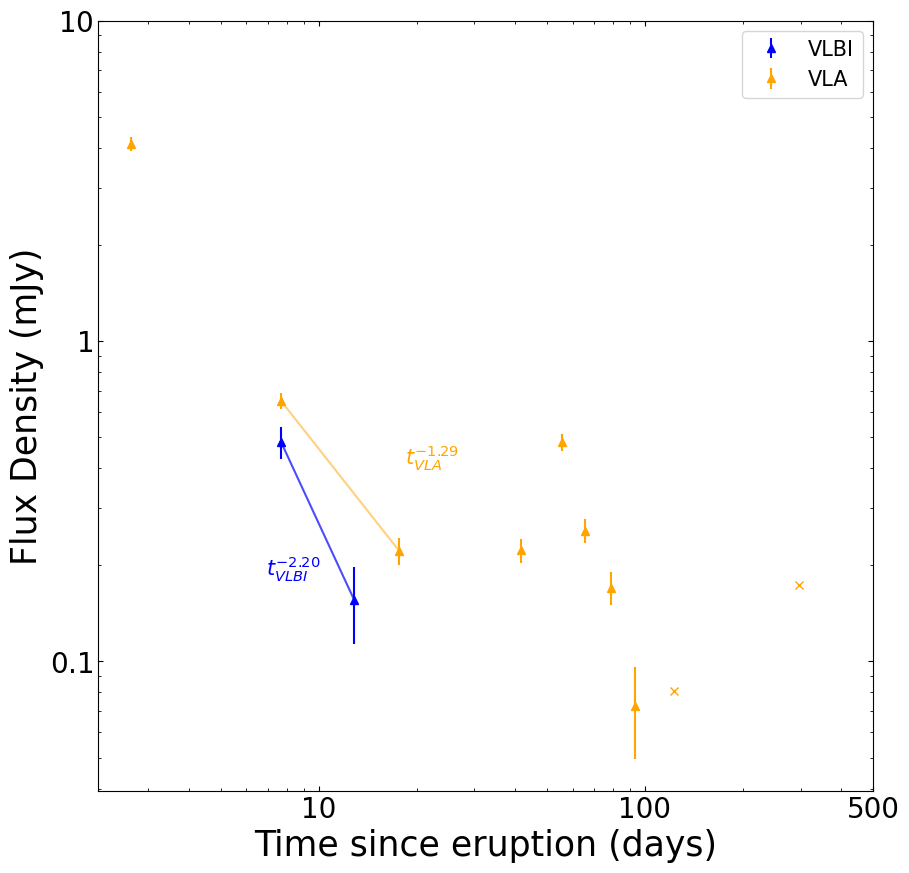

In [18]:
fig, ax = plt.subplots()
fig.set_size_inches(10,10)

# Store which labels have already been used
used_labels = set()

def plot(days, fluxes, errors, color, label_name):
    for day, flux, err in zip(days, fluxes, errors):
        if flux < 3 * err:
            fmt = 'x'  # square for non-detection
            label = None  # no label for non-detections

            ax.errorbar(day, (flux+3*err), fmt=fmt, color=color, label=label)
            
        if flux > 3*err :
            fmt = '^'  # triangle for detection
            label = label_name if label_name not in used_labels else None
        
            ax.errorbar(day, flux, yerr=err, fmt=fmt, color=color, label=label)
        
        if label:
            used_labels.add(label)


plot(days_VLBA_1535, flux_VLBA_1535, flux_err_VLBA_1535, 'blue', 'VLBI')
ax.plot(days_VLBA_1535, flux_VLBA_1535, color='blue', linestyle = '-', alpha=0.7)
ax.annotate('$t_{VLBI}^{-2.20}$', xy=(160, 170), xycoords='axes points', size=15, color='blue', ha='right', va='top', bbox=dict(boxstyle='round', fc='w', ec="w"))

plot(days4_55, flux4_55, flux_err4_55, 'orange', "VLA")
ax.plot(x1, y1, color='orange',  linestyle = '-', alpha=0.5)
ax.annotate('$t_{VLA}^{-1.29}$', xy=(260, 250), xycoords='axes points', size=15, color='orange', ha='right', va='top', bbox=dict(boxstyle='round', fc='w', ec="w"))


# Final plot formatting
ax.set_xscale('log')
ax.set_xticks([10,100,500], labels = ['10','100','500'], fontsize = 20)
ax.set_yscale('log')
ax.set_yticks([0.1, 1,10], labels = [r'$0.1$', r'$1$', r'$10$'], fontsize = 20)
ax.set_xlabel("Time since eruption (days)", fontsize = 25)
ax.set_ylabel("Flux Density (mJy)", fontsize = 25)

ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)

ax.set_title("")
plt.legend(fontsize = 15)
plt.savefig("V1535Sco_VLA_vs_VLBA_lc.png")
plt.show()

### finding correlations betwwwen VLBI vs VLA data

In [19]:
import numpy as np

In [20]:
#point 1

#VLBI data
#[57072.5, 4.87, 0.484, 0.0505], #VLBA

#VLA data
#[57072.5, 4.55, 0.65, 0.0168],

VLBI1 = 0.484
VLA1 = 0.65

diff1 = VLBI1/VLA1

print("keep in mind there is a difference of  0.32 in the frequency, VLBI data from 4.87 GHz and VLA data from 4.55 GHz")
print('')
print("The VLBI gets", diff1*100, "% of the VLA data at point 1")

keep in mind there is a difference of  0.32 in the frequency, VLBI data from 4.87 GHz and VLA data from 4.55 GHz

The VLBI gets 74.46153846153845 % of the VLA data at point 1


#### Using the percent change formula of

$\frac{New Value - Old Value}{|Old Value|} \times 100%$

In [21]:
perchange1 = (VLBI1-VLA1)/VLA1
print("The percentage change between the VLA to VLBI data for point 1 is", perchange1*100, "%")

The percentage change between the VLA to VLBI data for point 1 is -25.538461538461544 %


#### Using the percentage Difference equation
$|\frac{first value - second value}{(first value + second value)/2}| \times  100$

In [22]:
perdif1 = np.abs((VLBI1-VLA1)/((VLBI1+VLA1)/2)) * 100
print("The percentage difference between the VLA and VLBI in the first point is", perdif1, "%")

The percentage difference between the VLA and VLBI in the first point is 29.27689594356262 %


In [23]:
#point 2

#VLBI data
#[57077.7, 4.87, 0.155, 0.0409], #VLBA

#VLA data
#[57082.5, 4.55, 0.221, 0.0181],

VLBI2 = 0.155
VLA2 = 0.221

diff2 = VLBI2/VLA2

print("keep in mind there is a difference of  0.32 in the frequency, VLBI data from 4.87 GHz and VLA data from 4.55 GHz")
print('')
print("The VLBI gets", diff2*100, "% of the VLA data at point 2")

keep in mind there is a difference of  0.32 in the frequency, VLBI data from 4.87 GHz and VLA data from 4.55 GHz

The VLBI gets 70.13574660633483 % of the VLA data at point 2


In [24]:
perchange2 = (VLBI2-VLA2)/VLA2
print("The percentage change between the VLA to VLBI data for point 2 is", perchange2*100, "%")

The percentage change between the VLA to VLBI data for point 2 is -29.86425339366516 %


In [25]:
perdif2 = np.abs((VLBI2-VLA2)/((VLBI2+VLA2)/2)) * 100
print("The percentage difference between the VLA and VLBI in the second point is", perdif2, "%")

The percentage difference between the VLA and VLBI in the second point is 35.1063829787234 %


In [26]:
#averaging those two points

avediff = (diff1+diff2)/2
avediffper = avediff*100

print("the average difference in the VLBI vs VLA data between the two points is", avediffper, "%")


#ave percent change

aveperchange = ((perchange1+perchange2)/2)*100
print("")
print("The average petcentage change between the VLA and VLBI data for both points is", aveperchange, "%")

aveperdif = ((perdif1+perdif2)/2)
print("")
print("The average petcentage change between the VLA and VLBI data for both points is", aveperdif, "%")

the average difference in the VLBI vs VLA data between the two points is 72.29864253393666 %

The average petcentage change between the VLA and VLBI data for both points is -27.70135746606335 %

The average petcentage change between the VLA and VLBI data for both points is 32.19163946114301 %


In [27]:
#overall slope

VLBIslope =  -2.19839109112093
VLAslope =  -1.2918816312259405

diffslope = np.abs(VLBIslope - VLAslope)

print("keep in mind there is a difference of 0.32 in the frequency, VLBI data from 4.87 GHz and VLA data from 4.55 GHz")
print('')
print("The difference in the slope is", diffslope)
print('')

perchangeslope = (VLBIslope-VLAslope)/VLAslope
print("The percentage change between the VLA to VLBI data for the slope is", perchangeslope*100, "%")

print("")

perdifslope = np.abs((VLBIslope-VLAslope)/((VLBIslope+VLAslope)/2)) * 100
print("The percentage difference between the VLA and VLBI in the slope is", perdifslope, "%")

keep in mind there is a difference of 0.32 in the frequency, VLBI data from 4.87 GHz and VLA data from 4.55 GHz

The difference in the slope is 0.9065094598949894

The percentage change between the VLA to VLBI data for the slope is 70.16969960589583 %

The percentage difference between the VLA and VLBI in the slope is 51.94490700345328 %
